In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("darkgrid")

In [6]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'Amazon Review for Sentiment Analysis.ipynb', 'data', 'test.ft.txt.bz2', 'train.ft.txt.bz2']


In [9]:
import bz2

data = []

with bz2.open("train.ft.txt.bz2", "rt", encoding='utf-8') as file:
    for i, line in enumerate(file):
        data.append(line.strip())
        if i == 100000:   # limit for speed
            break

train_df = pd.DataFrame(data, columns=["text"])

train_df.head()

,text
0,__label__2 Stuning even for the non-gamer: Thi...
1,__label__2 The best soundtrack ever to anythin...
2,__label__2 Amazing!: This soundtrack is my fav...
3,__label__2 Excellent Soundtrack: I truly like ...
4,"__label__2 Remember, Pull Your Jaw Off The Flo..."


In [10]:
# Convert label (1 = positive, 0 = negative)
train_df['label'] = train_df['text'].apply(lambda x: 1 if '__label__2' in x else 0)

# Remove label text from review
train_df['text'] = train_df['text'].str.replace('__label__1 ', '', regex=False)
train_df['text'] = train_df['text'].str.replace('__label__2 ', '', regex=False)

train_df.head()

,text,label
0,Stuning even for the non-gamer: This sound tra...,1
1,The best soundtrack ever to anything.: I'm rea...,1
2,Amazing!: This soundtrack is my favorite music...,1
3,Excellent Soundtrack: I truly like this soundt...,1
4,"Remember, Pull Your Jaw Off The Floor After He...",1


In [11]:
print(train_df.shape)
print(train_df['label'].value_counts())

(100001, 2)
label
1    51268
0    48733
Name: count, dtype: int64


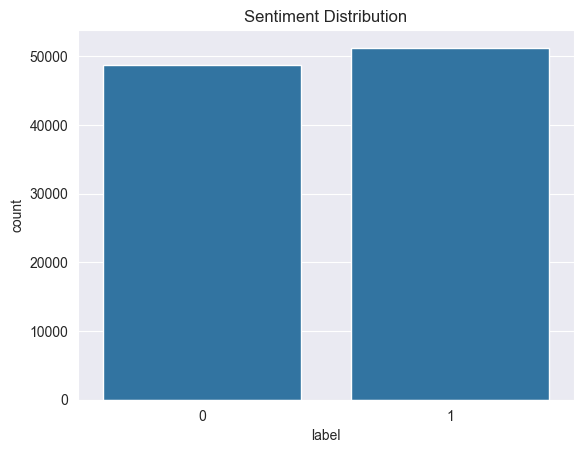

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label', data=train_df)
plt.title("Sentiment Distribution")
plt.show()

In [13]:
import re

def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove special characters
    return text

train_df['text'] = train_df['text'].apply(clean_text)

train_df.head()

,text,label
0,stuning even for the nongamer this sound track...,1
1,the best soundtrack ever to anything im readin...,1
2,amazing this soundtrack is my favorite music o...,1
3,excellent soundtrack i truly like this soundtr...,1
4,remember pull your jaw off the floor after hea...,1


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(train_df['text'])
y = train_df['label']

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [17]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8896555172241388
              precision    recall  f1-score   support

           0       0.89      0.88      0.89      9683
           1       0.89      0.89      0.89     10318

    accuracy                           0.89     20001
   macro avg       0.89      0.89      0.89     20001
weighted avg       0.89      0.89      0.89     20001



In [19]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def clean_text(text):
    text = text.lower()  # small letters
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove symbols
    
    words = text.split()
    
    # remove common useless words
    words = [word for word in words if word not in ENGLISH_STOP_WORDS]
    
    return " ".join(words)

train_df['text'] = train_df['text'].apply(clean_text)
train_df.head()

,text,label
0,stuning nongamer sound track beautiful paints ...,1
1,best soundtrack im reading lot reviews saying ...,1
2,amazing soundtrack favorite music time hands i...,1
3,excellent soundtrack truly like soundtrack enj...,1
4,remember pull jaw floor hearing youve played g...,1


In [20]:
print("Before cleaning:")
print(train_df['text'].iloc[0])

train_df['text'] = train_df['text'].apply(clean_text)

print("\nAfter cleaning:")
print(train_df['text'].iloc[0])

Before cleaning:
stuning nongamer sound track beautiful paints senery mind recomend people hate vid game music played game chrono cross games played best music backs away crude keyboarding takes fresher step grate guitars soulful orchestras impress cares listen

After cleaning:
stuning nongamer sound track beautiful paints senery mind recomend people hate vid game music played game chrono cross games played best music backs away crude keyboarding takes fresher step grate guitars soulful orchestras impress cares listen
